In [1]:
import pandas as pd

df = pd.read_csv('model.csv')

print(df.shape)      # 查看行列数
print(df.columns)    # 查看列名
df.head()

(511886, 21)
Index(['loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade',
       'homeOwnership', 'verificationStatus', 'isDefault', 'dti',
       'ficoRangeLow', 'ficoRangeHigh', 'title', 'n2', 'n3', 'n9', 'n14',
       'annualIncome_log', 'revol_flag', 'issueDateDT', 'creditAge'],
      dtype='object')


,loanAmnt,term,interestRate,installment,grade,subGrade,homeOwnership,verificationStatus,isDefault,dti,...,ficoRangeHigh,title,n2,n3,n9,n14,annualIncome_log,revol_flag,issueDateDT,creditAge
0,35000.0,5,19.52,917.97,4,21,2,2,1.0,17.05,...,734.0,1.0,2.000000,2.000000,2.000000,2.000000,11.608245,1,2587,13
1,18000.0,5,18.49,461.90,3,16,0,2,0.0,27.83,...,704.0,1723.0,5.646404,5.646404,5.594498,2.178891,10.736418,1,1888,10
2,12000.0,5,16.99,298.17,3,17,0,2,0.0,22.77,...,679.0,0.0,3.000000,3.000000,3.000000,4.000000,11.211834,1,3044,9
3,11000.0,3,7.26,340.96,0,3,1,1,0.0,17.21,...,689.0,4.0,6.000000,6.000000,6.000000,1.000000,11.678448,1,2983,16
4,3000.0,3,12.99,101.07,2,11,1,2,0.0,32.16,...,694.0,11.0,7.000000,7.000000,7.000000,4.000000,10.275086,1,3196,39


In [3]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_csv("model.csv")

# 需要转整数的变量
int_cols = ['loanAmnt','n2','n3','n9','n14']

for col in int_cols:
    df[col] = df[col].round().astype(int)

print(df[int_cols].head())

print("\n数据类型：")
print(df[int_cols].dtypes)

   loanAmnt  n2  n3  n9  n14
0     35000   2   2   2    2
1     18000   6   6   6    2
2     12000   3   3   3    4
3     11000   6   6   6    1
4      3000   7   7   7    4

数据类型：
loanAmnt    int32
n2          int32
n3          int32
n9          int32
n14         int32
dtype: object


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('isDefault',axis=1)
y = df['isDefault']

# 测试集10%
X_temp,X_test,y_temp,y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# 验证集20%
X_train,X_val,y_train,y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=2/9,
    random_state=42,
    stratify=y_temp
)

print("训练集:",X_train.shape)
print("验证集:",X_val.shape)
print("测试集:",X_test.shape)

训练集: (358319, 20)
验证集: (102378, 20)
测试集: (51189, 20)


In [7]:
!pip install optuna

   ---------------------------------------- 0.0/419.5 kB ? eta -:--:--
   -- ------------------------------------- 30.7/419.5 kB 1.3 MB/s eta 0:00:01
   --- ----------------------------------- 41.0/419.5 kB 393.8 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/419.5 kB 744.7 kB/s eta 0:00:01
   ----------- -------------------------- 122.9/419.5 kB 654.9 kB/s eta 0:00:01
   --------------------- ------------------ 225.3/419.5 kB 1.1 MB/s eta 0:00:01
   --------------------------- ------------ 286.7/419.5 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------  409.6/419.5 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 419.5/419.5 kB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/263.9 kB ? eta -:--:--
   ---------------------------------------- 263.9/263.9 kB 5.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/44.6 kB ? eta -:--:--
   ---------------------------------------- 44.6/44.6 kB 2.3 MB/s eta

In [9]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def objective_xgb(trial):

    params = {

        'learning_rate':
        trial.suggest_float(
            'learning_rate',
            0.01,
            0.1
        ),

        'max_depth':
        trial.suggest_int(
            'max_depth',
            3,
            7
        ),

        'n_estimators':
        trial.suggest_int(
            'n_estimators',
            100,
            500
        ),

        'min_child_weight':
        trial.suggest_int(
            'min_child_weight',
            1,
            10
        ),

        'subsample':
        trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree':
        trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'eval_metric':'auc',

        'random_state':42
    }

    model = XGBClassifier(**params)

    model.fit(X_train,y_train)

    pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val,pred)

    return auc

study_xgb = optuna.create_study(
    direction='maximize'
)

study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

print("最佳AUC")
print(study_xgb.best_value)

print("\n最佳参数")
print(study_xgb.best_params)

[I 2026-05-21 07:34:35,797] A new study created in memory with name: no-name-502fe2e5-c00f-4215-92e8-ca3d1b622543
[I 2026-05-21 07:34:42,092] Trial 0 finished with value: 0.725837657162403 and parameters: {'learning_rate': 0.05840278086161796, 'max_depth': 5, 'n_estimators': 375, 'min_child_weight': 4, 'subsample': 0.6492729636493904, 'colsample_bytree': 0.8247607573075134}. Best is trial 0 with value: 0.725837657162403.
[I 2026-05-21 07:34:51,274] Trial 1 finished with value: 0.72481503400976 and parameters: {'learning_rate': 0.04753364131402365, 'max_depth': 7, 'n_estimators': 450, 'min_child_weight': 1, 'subsample': 0.9304350970526423, 'colsample_bytree': 0.9216981113095951}. Best is trial 0 with value: 0.725837657162403.
[I 2026-05-21 07:34:56,781] Trial 2 finished with value: 0.7249534124979365 and parameters: {'learning_rate': 0.0878064840415431, 'max_depth': 3, 'n_estimators': 447, 'min_child_weight': 10, 'subsample': 0.9369470940180428, 'colsample_bytree': 0.9490320153879148}. 

最佳AUC
0.7258998065712507

最佳参数
{'learning_rate': 0.08012206592573855, 'max_depth': 4, 'n_estimators': 479, 'min_child_weight': 7, 'subsample': 0.8162952857805357, 'colsample_bytree': 0.9243187815157176}


In [10]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):

    params = {

        'n_estimators':
        trial.suggest_int(
            'n_estimators',
            100,
            300
        ),

        'max_depth':
        trial.suggest_int(
            'max_depth',
            5,
            15
        ),

        'min_samples_split':
        trial.suggest_int(
            'min_samples_split',
            2,
            10
        ),

        'min_samples_leaf':
        trial.suggest_int(
            'min_samples_leaf',
            1,
            5
        ),

        'random_state':42,

        'n_jobs':-1
    }

    model = RandomForestClassifier(**params)

    model.fit(X_train,y_train)

    pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val,pred)

    return auc

study_rf = optuna.create_study(
    direction='maximize'
)

study_rf.optimize(
    objective_rf,
    n_trials=50
)

print("最佳AUC")
print(study_rf.best_value)

print("\n最佳参数")
print(study_rf.best_params)

[I 2026-05-21 07:40:04,206] A new study created in memory with name: no-name-62ba4366-0443-4f81-ad96-860eea46405f
[I 2026-05-21 07:40:22,717] Trial 0 finished with value: 0.7126872634020115 and parameters: {'n_estimators': 141, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7126872634020115.
[I 2026-05-21 07:41:14,409] Trial 1 finished with value: 0.7184966090759348 and parameters: {'n_estimators': 232, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7184966090759348.
[I 2026-05-21 07:41:30,670] Trial 2 finished with value: 0.7171578859217362 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.7184966090759348.
[I 2026-05-21 07:41:57,881] Trial 3 finished with value: 0.7079438026461233 and parameters: {'n_estimators': 279, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 

最佳AUC
0.7198440041420942

最佳参数
{'n_estimators': 288, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 4}


In [11]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

In [12]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    eval_metric='auc',
    random_state=42
)

best_xgb.fit(X_train,y_train)

xgb_pred = best_xgb.predict_proba(X_val)[:,1]

fpr_xgb,tpr_xgb,_ = roc_curve(
    y_val,
    xgb_pred
)

auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

In [13]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train,y_train)

rf_pred = best_rf.predict_proba(X_val)[:,1]

fpr_rf,tpr_rf,_ = roc_curve(
    y_val,
    rf_pred
)

auc_rf = auc(
    fpr_rf,
    tpr_rf
)

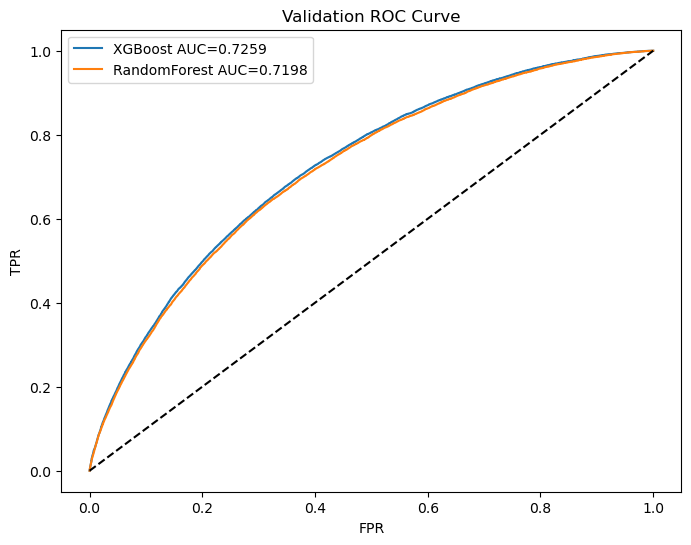

In [14]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost AUC={auc_xgb:.4f}'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'RandomForest AUC={auc_rf:.4f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.title('Validation ROC Curve')

plt.legend()

plt.show()

In [15]:
if auc_xgb > auc_rf:
    best_model = best_xgb
    model_name = "XGBoost"
else:
    best_model = best_rf
    model_name = "RandomForest"

print("最佳模型:",model_name)

最佳模型: XGBoost


In [16]:
X_train_final = pd.concat(
    [X_train,X_val]
)

y_train_final = pd.concat(
    [y_train,y_val]
)

best_model.fit(
    X_train_final,
    y_train_final
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9243187815157176, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08012206592573855,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=479, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
from sklearn.metrics import roc_auc_score

test_pred = best_model.predict_proba(X_test)[:,1]

test_auc = roc_auc_score(
    y_test,
    test_pred
)

print("测试集AUC =",test_auc)

测试集AUC = 0.720883909959305


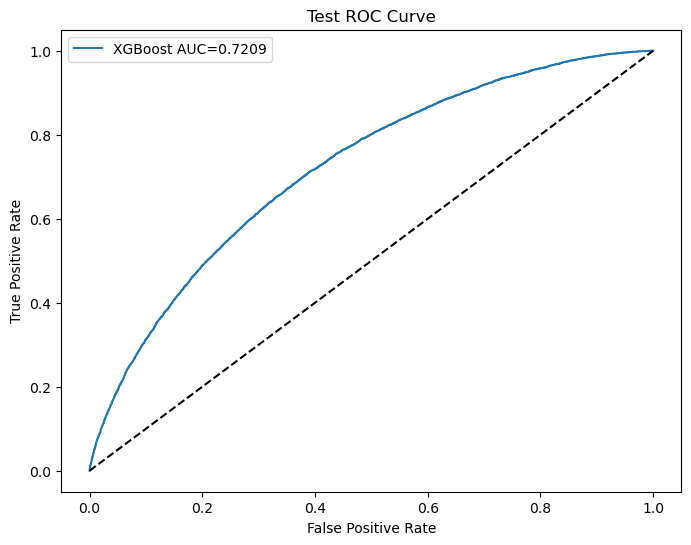

In [18]:
fpr,tpr,_ = roc_curve(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'{model_name} AUC={test_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Test ROC Curve')

plt.legend()

plt.show()

In [29]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve,
    precision_score, recall_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# =========================
# 1. 训练集 / 验证集 / 测试集 AUC
# =========================

train_pred = best_model.predict_proba(X_train_final)[:, 1]
test_pred = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train_final, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

print("训练集 AUC:", round(train_auc, 4))
print("测试集 AUC:", round(test_auc, 4))
print("AUC 差值:", round(train_auc - test_auc, 4))

if train_auc - test_auc < 0.02:
    print("模型过拟合风险较低")
else:
    print("模型可能存在一定过拟合")

训练集 AUC: 0.7378
测试集 AUC: 0.7209
AUC 差值: 0.0169
模型过拟合风险较低


In [33]:
# =========================
# 2. KS 值计算
# =========================

def calculate_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks_values = tpr - fpr
    best_index = np.argmax(ks_values)
    
    return {
        "KS": ks_values[best_index],
        "Best Threshold": thresholds[best_index],
        "TPR": tpr[best_index],
        "FPR": fpr[best_index]
    }

ks_result = calculate_ks(y_test, test_pred)

print("测试集 KS 值:", round(ks_result["KS"], 4))
print("KS 对应阈值:", round(ks_result["Best Threshold"], 4))
print("TPR:", round(ks_result["TPR"], 4))
print("FPR:", round(ks_result["FPR"], 4))

测试集 KS 值: 0.322
KS 对应阈值: 0.1821
TPR: 0.7122
FPR: 0.3902


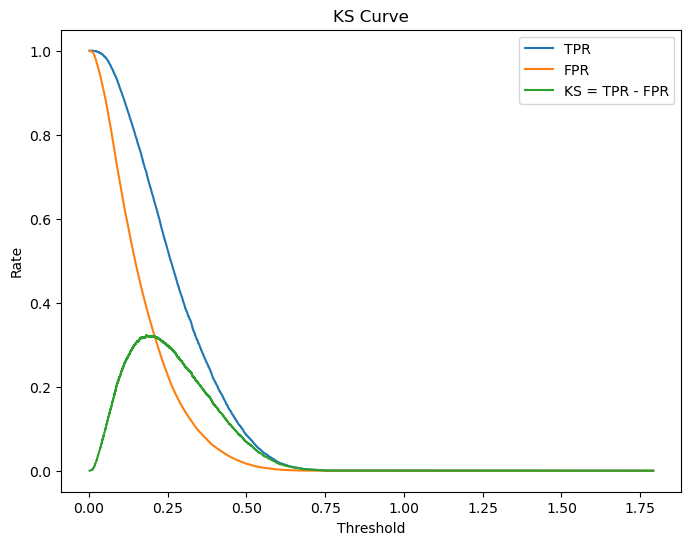

In [35]:
# KS 曲线
fpr, tpr, thresholds = roc_curve(y_test, test_pred)
ks_values = tpr - fpr

plt.figure(figsize=(8,6))
plt.plot(thresholds, tpr, label="TPR")
plt.plot(thresholds, fpr, label="FPR")
plt.plot(thresholds, ks_values, label="KS = TPR - FPR")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Curve")
plt.legend()
plt.show()

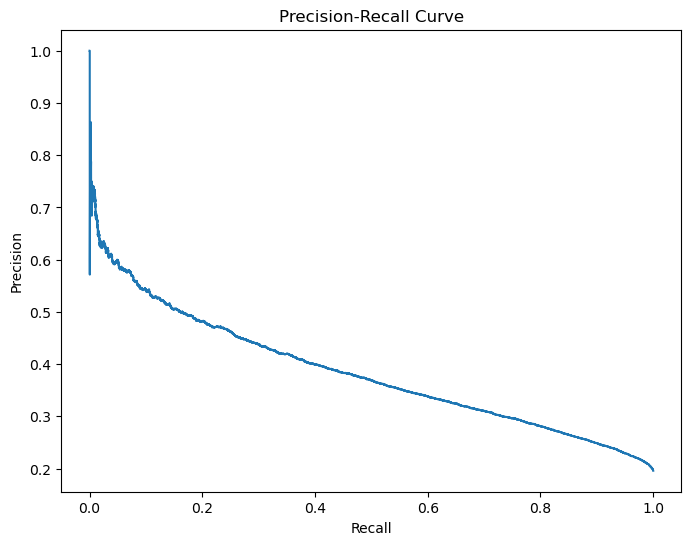

In [37]:
# =========================
# 3. 精确率 - 召回率曲线
# =========================

precision, recall, thresholds_pr = precision_recall_curve(y_test, test_pred)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [39]:
# =========================
# 5. 逻辑回归系数表
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train_final, y_train_final)

lr_coef = lr_model.named_steps["lr"].coef_[0]

coef_table = pd.DataFrame({
    "feature": X_train_final.columns,
    "coefficient": lr_coef,
    "abs_coefficient": np.abs(lr_coef)
}).sort_values(
    by="abs_coefficient",
    ascending=False
)

coef_table.head(20)

,feature,coefficient,abs_coefficient
5,subGrade,0.512203,0.512203
1,term,0.270063,0.270063
16,annualIncome_log,-0.207415,0.207415
3,installment,0.190048,0.190048
18,issueDateDT,0.166189,0.166189
2,interestRate,-0.140370,0.140370
6,homeOwnership,0.113977,0.113977
9,ficoRangeLow,-0.089501,0.089501
10,ficoRangeHigh,-0.089363,0.089363
15,n14,0.088879,0.088879


               feature  importance
4                grade    0.517660
5             subGrade    0.252009
1                 term    0.062310
6        homeOwnership    0.029526
18         issueDateDT    0.015794
13                  n3    0.014184
12                  n2    0.012702
15                 n14    0.011017
9         ficoRangeLow    0.010772
7   verificationStatus    0.009749


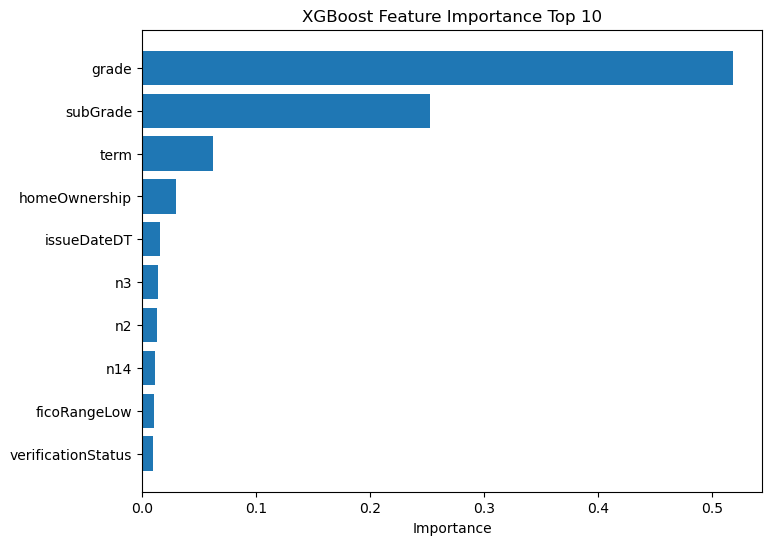

In [41]:
# =========================
# 6. XGBoost 特征重要性 Top10
# =========================

xgb_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": best_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

xgb_top10 = xgb_importance.head(10)

print(xgb_top10)

plt.figure(figsize=(8,6))
plt.barh(
    xgb_top10["feature"][::-1],
    xgb_top10["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance Top 10")
plt.show()

In [43]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve

In [44]:
# 计算 KS
def calculate_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks_values = tpr - fpr
    best_idx = np.argmax(ks_values)

    return {
        "KS": ks_values[best_idx],
        "threshold": thresholds[best_idx],
        "TPR": tpr[best_idx],
        "FPR": fpr[best_idx]
    }

In [45]:
# 类别不平衡权重
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 4.102950810333533


In [46]:
# LightGBM + Optuna
def objective_lgb(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),

        "scale_pos_weight": scale_pos_weight,

        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc"
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred)

    return val_auc

In [47]:
study_lgb = optuna.create_study(direction="maximize")

study_lgb.optimize(
    objective_lgb,
    n_trials=100
)

print("LightGBM 最佳验证集 AUC:", study_lgb.best_value)
print("LightGBM 最佳参数:")
print(study_lgb.best_params)

[I 2026-05-21 08:41:49,654] A new study created in memory with name: no-name-be350970-63c6-4ba2-9c0a-7ef7eade5d49
[I 2026-05-21 08:42:17,537] Trial 0 finished with value: 0.7254728264775814 and parameters: {'learning_rate': 0.046966772402870095, 'n_estimators': 917, 'num_leaves': 27, 'max_depth': 7, 'min_child_samples': 57, 'subsample': 0.8157238910966134, 'colsample_bytree': 0.7108287292098915, 'reg_alpha': 7.855324797297252, 'reg_lambda': 7.090855870778982}. Best is trial 0 with value: 0.7254728264775814.
[I 2026-05-21 08:42:27,626] Trial 1 finished with value: 0.724838659686533 and parameters: {'learning_rate': 0.09527490975054845, 'n_estimators': 274, 'num_leaves': 20, 'max_depth': 5, 'min_child_samples': 61, 'subsample': 0.8328874846755304, 'colsample_bytree': 0.6035263115071642, 'reg_alpha': 1.0068415039307388, 'reg_lambda': 5.621985302581553}. Best is trial 0 with value: 0.7254728264775814.
[I 2026-05-21 08:42:42,269] Trial 2 finished with value: 0.7250162488898245 and parameter

LightGBM 最佳验证集 AUC: 0.7258761851332447
LightGBM 最佳参数:
{'learning_rate': 0.07210222232025912, 'n_estimators': 778, 'num_leaves': 16, 'max_depth': 8, 'min_child_samples': 43, 'subsample': 0.845893238436561, 'colsample_bytree': 0.6192209114870332, 'reg_alpha': 6.560005576242192, 'reg_lambda': 0.0015068022747918297}


In [52]:
# 用最佳参数训练 LightGBM
best_lgb = LGBMClassifier(
    **study_lgb.best_params,
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_lgb.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.6192209114870332,
               learning_rate=0.07210222232025912, max_depth=8, metric='auc',
               min_child_samples=43, n_estimators=778, n_jobs=-1, num_leaves=16,
               objective='binary', random_state=42, reg_alpha=6.560005576242192,
               reg_lambda=0.0015068022747918297,
               scale_pos_weight=4.102950810333533, subsample=0.845893238436561,
               verbose=-1)

In [53]:
# 验证集 AUC 和 KS
val_pred_lgb = best_lgb.predict_proba(X_val)[:, 1]

val_auc_lgb = roc_auc_score(y_val, val_pred_lgb)
val_ks_lgb = calculate_ks(y_val, val_pred_lgb)

print("验证集 AUC:", round(val_auc_lgb, 4))
print("验证集 KS:", round(val_ks_lgb["KS"], 4))
print("KS 对应阈值:", round(val_ks_lgb["threshold"], 4))
print("TPR:", round(val_ks_lgb["TPR"], 4))
print("FPR:", round(val_ks_lgb["FPR"], 4))

验证集 AUC: 0.7259
验证集 KS: 0.3297
KS 对应阈值: 0.5051
TPR: 0.6653
FPR: 0.3356


In [54]:
# 训练集 + 验证集合并后，再训练最终模型
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

best_lgb_final = LGBMClassifier(
    **study_lgb.best_params,
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_lgb_final.fit(X_train_final, y_train_final)

LGBMClassifier(colsample_bytree=0.6192209114870332,
               learning_rate=0.07210222232025912, max_depth=8, metric='auc',
               min_child_samples=43, n_estimators=778, n_jobs=-1, num_leaves=16,
               objective='binary', random_state=42, reg_alpha=6.560005576242192,
               reg_lambda=0.0015068022747918297,
               scale_pos_weight=4.102950810333533, subsample=0.845893238436561,
               verbose=-1)

In [60]:
type(best_lgb_final)

lightgbm.sklearn.LGBMClassifier

In [68]:
test_pred_lgb = best_lgb_final.predict_proba(X_test)[:,1]

In [70]:
# 画测试集 ROC 曲线
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, test_pred_lgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM AUC={test_auc_lgb:.4f}")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM Test ROC Curve")
plt.legend()
plt.show()

NameError: name 'test_auc_lgb' is not defined

<Figure size 800x600 with 0 Axes>

In [66]:
print("XGBoost 测试集 AUC:", round(test_auc, 4))
print("XGBoost 测试集 KS:", 0.322)

print("LightGBM 测试集 AUC:", round(test_auc_lgb, 4))
print("LightGBM 测试集 KS:", round(test_ks_lgb["KS"], 4))

XGBoost 测试集 AUC: 0.7209
XGBoost 测试集 KS: 0.322


NameError: name 'test_auc_lgb' is not defined

LightGBM 测试集 AUC: 0.7209


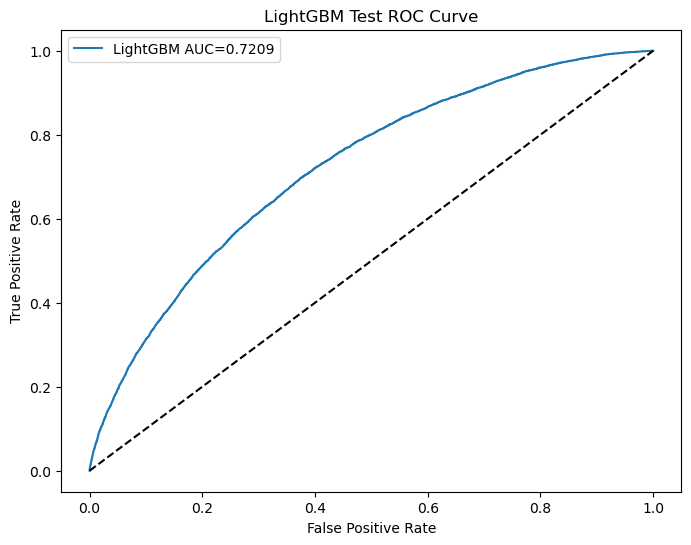

In [72]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. 生成 LightGBM 测试集预测概率
test_pred_lgb = best_lgb_final.predict_proba(X_test)[:, 1]

# 2. 计算测试集 AUC
test_auc_lgb = roc_auc_score(y_test, test_pred_lgb)

print("LightGBM 测试集 AUC:", round(test_auc_lgb, 4))

# 3. 计算 ROC 曲线
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, test_pred_lgb)

# 4. 画 ROC 图
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lgb,
    tpr_lgb,
    label=f"LightGBM AUC={test_auc_lgb:.4f}"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM Test ROC Curve")
plt.legend()
plt.show()